In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('customers_clean.csv')

In [3]:
df.shape

(348907, 12)

In [4]:
df.sample(10)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,total_price,year_month,day_of_week,hour
295514,575852,22617,BAKING SET SPACEBOY DESIGN,2,2011-11-11 12:17:00,4.95,17238.0,United Kingdom,9.90,2011-11,Friday,12
200315,565418,82582,AREA PATROLLED METAL SIGN,12,2011-09-04 12:07:00,2.10,13576.0,United Kingdom,25.20,2011-09,Sunday,12
346071,581192,21616,4 PEAR BOTANICAL DINNER CANDLES,2,2011-12-07 17:05:00,3.75,15883.0,United Kingdom,7.50,2011-12,Wednesday,17
103061,551462,22824,3 TIER SWEETHEART GARDEN SHELF,1,2011-04-28 16:11:00,35.95,15210.0,United Kingdom,35.95,2011-04,Thursday,16
149117,558232,20719,WOODLAND CHARLOTTE BAG,5,2011-06-27 14:30:00,0.85,17841.0,United Kingdom,4.25,2011-06,Monday,14
240212,569825,22895,SET OF 2 TEA TOWELS APPLE AND PEARS,6,2011-10-06 12:23:00,3.25,15805.0,United Kingdom,19.50,2011-10,Thursday,12
113481,553006,21242,RED RETROSPOT PLATE,8,2011-05-12 16:45:00,1.69,15544.0,United Kingdom,13.52,2011-05,Thursday,16
1727,536597,85035C,ROSE 3 WICK MORRIS BOX CANDLE,1,2010-12-01 17:35:00,4.25,18011.0,United Kingdom,4.25,2010-12,Wednesday,17
202051,565613,84725,FREESTYLE CANVAS ART PICTURE,1,2011-09-05 15:19:00,0.75,13744.0,United Kingdom,0.75,2011-09,Monday,15
73077,547108,22410,MONEY BOX HOUSEKEEPING DESIGN,3,2011-03-21 11:36:00,1.25,14659.0,United Kingdom,3.75,2011-03,Monday,11


In [6]:
df.isnull().sum()

invoiceno      0
stockcode      0
description    0
quantity       0
invoicedate    0
unitprice      0
customerid     0
country        0
total_price    0
year_month     0
day_of_week    0
hour           0
dtype: int64

In [9]:
df.dtypes

invoiceno               int64
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
customerid            float64
country                object
total_price           float64
year_month             object
day_of_week            object
hour                    int64
dtype: object

In [8]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [11]:
last_invoice_date = df['invoicedate'].max()

# 2. Add exactly one day to simulate running the report the morning after
snapshot_date = last_invoice_date + pd.Timedelta(days=1)

print(f"Last transaction found: {last_invoice_date}")
print(f"Snapshot date set to:   {snapshot_date}")

Last transaction found: 2011-12-09 12:49:00
Snapshot date set to:   2011-12-10 12:49:00


In [16]:
rfm = df.groupby('customerid').agg({
    'invoicedate': lambda x: (snapshot_date - x.max()).days,
    'invoiceno': 'nunique',       # Count of unique invoices
    'total_price': 'sum'          # Sum of all revenue
}).reset_index()

In [18]:
rfm.rename(columns={
    'invoicedate': 'Recency',
    'invoiceno': 'Frequency',
    'total_price': 'Monetary'
}, inplace=True)

In [19]:
print("--- RFM DataFrame Preview ---")
print(rfm.head())

print(f"\nTotal Customers Profiled: {len(rfm):,}")

# Quick sanity check on the distributions
print("\n--- RFM Statistical Summary ---")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

--- RFM DataFrame Preview ---
   customerid  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12747.0        2         11   4196.01
2     12748.0        1        206  31650.78
3     12749.0        4          5   4090.88
4     12820.0        3          4    942.34

Total Customers Profiled: 3,917

--- RFM Statistical Summary ---
       Recency  Frequency   Monetary
count  3917.00    3917.00    3917.00
mean     92.36       4.24    1849.30
std      99.75       7.16    7430.42
min       1.00       1.00       3.75
25%      18.00       1.00     298.00
50%      51.00       2.00     644.30
75%     143.00       5.00    1567.48
max     374.00     206.00  259657.30



--- 1. Visualizing Raw Data ---


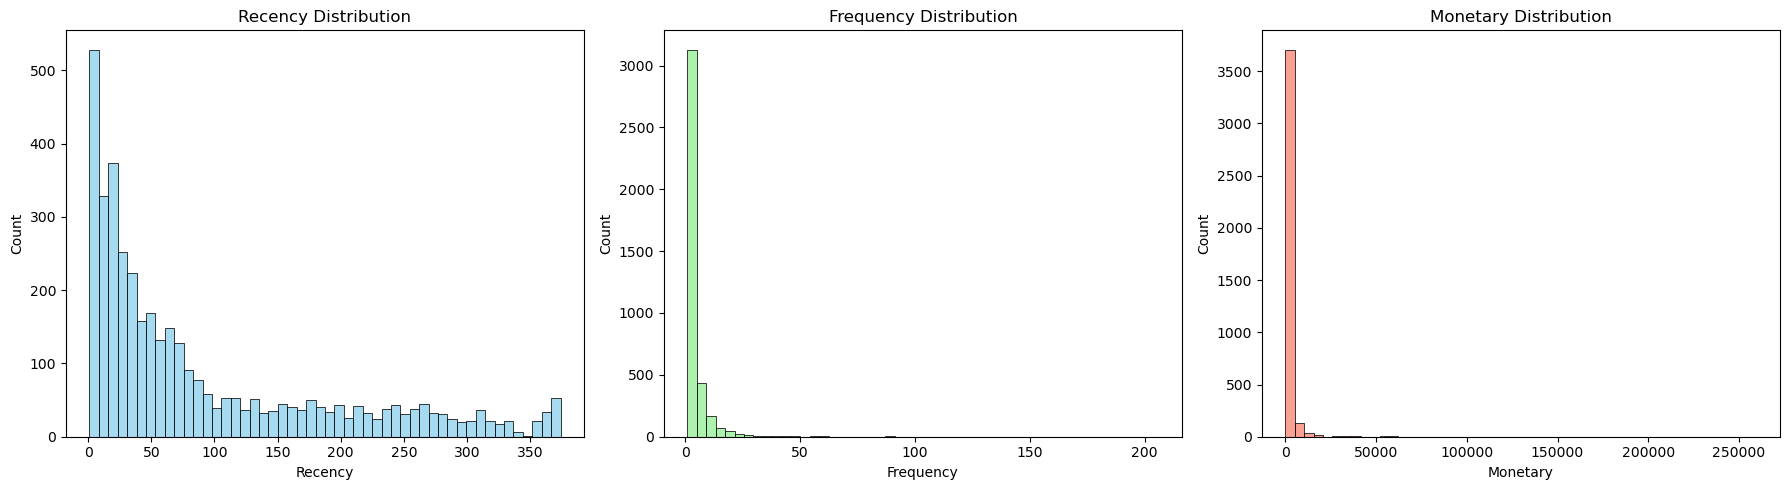

In [20]:
print("\n--- 1. Visualizing Raw Data ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=50, ax=axes[1], color='lightgreen')
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=50, ax=axes[2], color='salmon')
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.savefig('rfm_raw_distributions.png')
# plt.show()

In [21]:
print("\n--- 2. Checking Monetary Outliers ---")
# Show the 95th and 99th percentiles vs the max
p95 = rfm['Monetary'].quantile(0.95)
p99 = rfm['Monetary'].quantile(0.99)
max_val = rfm['Monetary'].max()

print(f"95th Percentile: ${p95:,.2f}")
print(f"99th Percentile: ${p99:,.2f}")
print(f"Absolute Max:    ${max_val:,.2f}")

if max_val > (p99 * 5):
    print("-> Result: Extreme bulk buyers detected. The max value heavily distorts the axis.")


--- 2. Checking Monetary Outliers ---
95th Percentile: $5,489.24
99th Percentile: $17,282.06
Absolute Max:    $259,657.30
-> Result: Extreme bulk buyers detected. The max value heavily distorts the axis.


In [22]:
print("\n--- 3. Applying Log Transformation ---")

rfm['R_log'] = np.log1p(rfm['Recency'])
rfm['F_log'] = np.log1p(rfm['Frequency'])
rfm['M_log'] = np.log1p(rfm['Monetary'])


--- 3. Applying Log Transformation ---



--- 4. Visualizing Log-Transformed Data ---


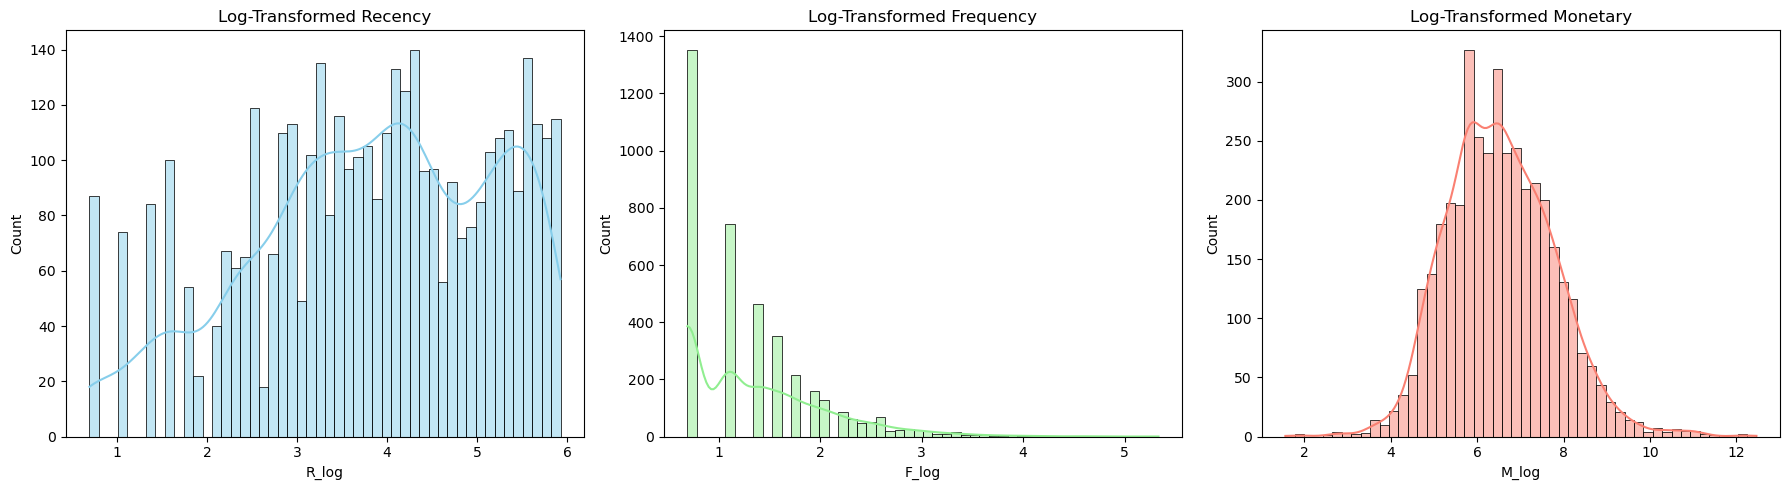

In [23]:
print("\n--- 4. Visualizing Log-Transformed Data ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['R_log'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Log-Transformed Recency')

sns.histplot(rfm['F_log'], bins=50, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title('Log-Transformed Frequency')

sns.histplot(rfm['M_log'], bins=50, ax=axes[2], color='salmon', kde=True)
axes[2].set_title('Log-Transformed Monetary')

plt.tight_layout()
plt.savefig('rfm_log_distributions.png')

In [24]:
r_labels = [5, 4, 3, 2, 1] 
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels)

f_labels = [1, 2, 3, 4, 5]
# We use .rank(method='first') to prevent ValueError from too many identical low frequencies (e.g., F=1)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)

m_labels = [1, 2, 3, 4, 5]
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

In [25]:
print("\n--- Scored RFM DataFrame Preview ---")
cols_to_show = ['customerid', 'Recency', 'R_Score', 'Frequency', 'F_Score', 'Monetary', 'M_Score', 'RFM_Segment', 'RFM_Score']
print(rfm[cols_to_show].head())

# Look at how many users fall into the absolute best and worst categories
print("\n--- Extreme Segments Count ---")
print(f"Champions (555): {len(rfm[rfm['RFM_Segment'] == '555']):,}")
print(f"Lost Cheap Customers (111): {len(rfm[rfm['RFM_Segment'] == '111']):,}")


--- Scored RFM DataFrame Preview ---
   customerid  Recency R_Score  Frequency F_Score  Monetary M_Score  \
0     12346.0      326       1          1       1  77183.60       5   
1     12747.0        2       5         11       5   4196.01       5   
2     12748.0        1       5        206       5  31650.78       5   
3     12749.0        4       5          5       4   4090.88       5   
4     12820.0        3       5          4       4    942.34       4   

  RFM_Segment  RFM_Score  
0         115          7  
1         555         15  
2         555         15  
3         545         14  
4         544         13  

--- Extreme Segments Count ---
Champions (555): 324
Lost Cheap Customers (111): 168


In [26]:
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)

conditions = [
    (rfm['R_Score'] == 5) & (rfm['F_Score'] == 5),        # Champions
    (rfm['R_Score'] <= 2) & (rfm['F_Score'] >= 3),        # At Risk (Must go before Loyal!)
    (rfm['F_Score'] >= 4),                                # Loyal Customers
    (rfm['R_Score'] == 1) & (rfm['F_Score'] == 1),        # Lost
    (rfm['R_Score'] >= 4) & (rfm['F_Score'] <= 2),        # Potential Loyalists
    (rfm['R_Score'] == 3) & (rfm['F_Score'] == 3)         # Needs Attention
]

choices = [
    'Champions',
    'At Risk',
    'Loyal Customers',
    'Lost',
    'Potential Loyalists',
    'Needs Attention'
]

rfm['Customer_Segment'] = np.select(conditions, choices, default='Others')

In [27]:
print("\n--- Customer Segmentation Summary ---")

segment_counts = rfm['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer Count']

segment_metrics = rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print(segment_counts)
print("\n--- Average Metrics per Segment ---")
print(segment_metrics)


--- Customer Segmentation Summary ---
               Segment  Customer Count
0               Others            1252
1      Loyal Customers             901
2              At Risk             591
3            Champions             403
4                 Lost             323
5  Potential Loyalists             284
6      Needs Attention             163

--- Average Metrics per Segment ---
                    Recency Frequency Monetary      
                       mean      mean     mean count
Customer_Segment                                    
At Risk               150.8       3.5   1231.0   591
Champions               5.8      15.6   8134.3   403
Lost                  278.5       1.0    532.2   323
Loyal Customers        27.9       6.0   2276.0   901
Needs Attention        51.8       2.3    834.0   163
Others                113.0       1.4    615.6  1252
Potential Loyalists    18.7       1.2    383.1   284


=== COHORT RETENTION ANALYSIS (OPTIMIZED) ===

--- 1. Calculating Cohorts & Time Offsets ---

--- 2. Building the Pivot Table ---

--- 3. Generating Heatmap ---


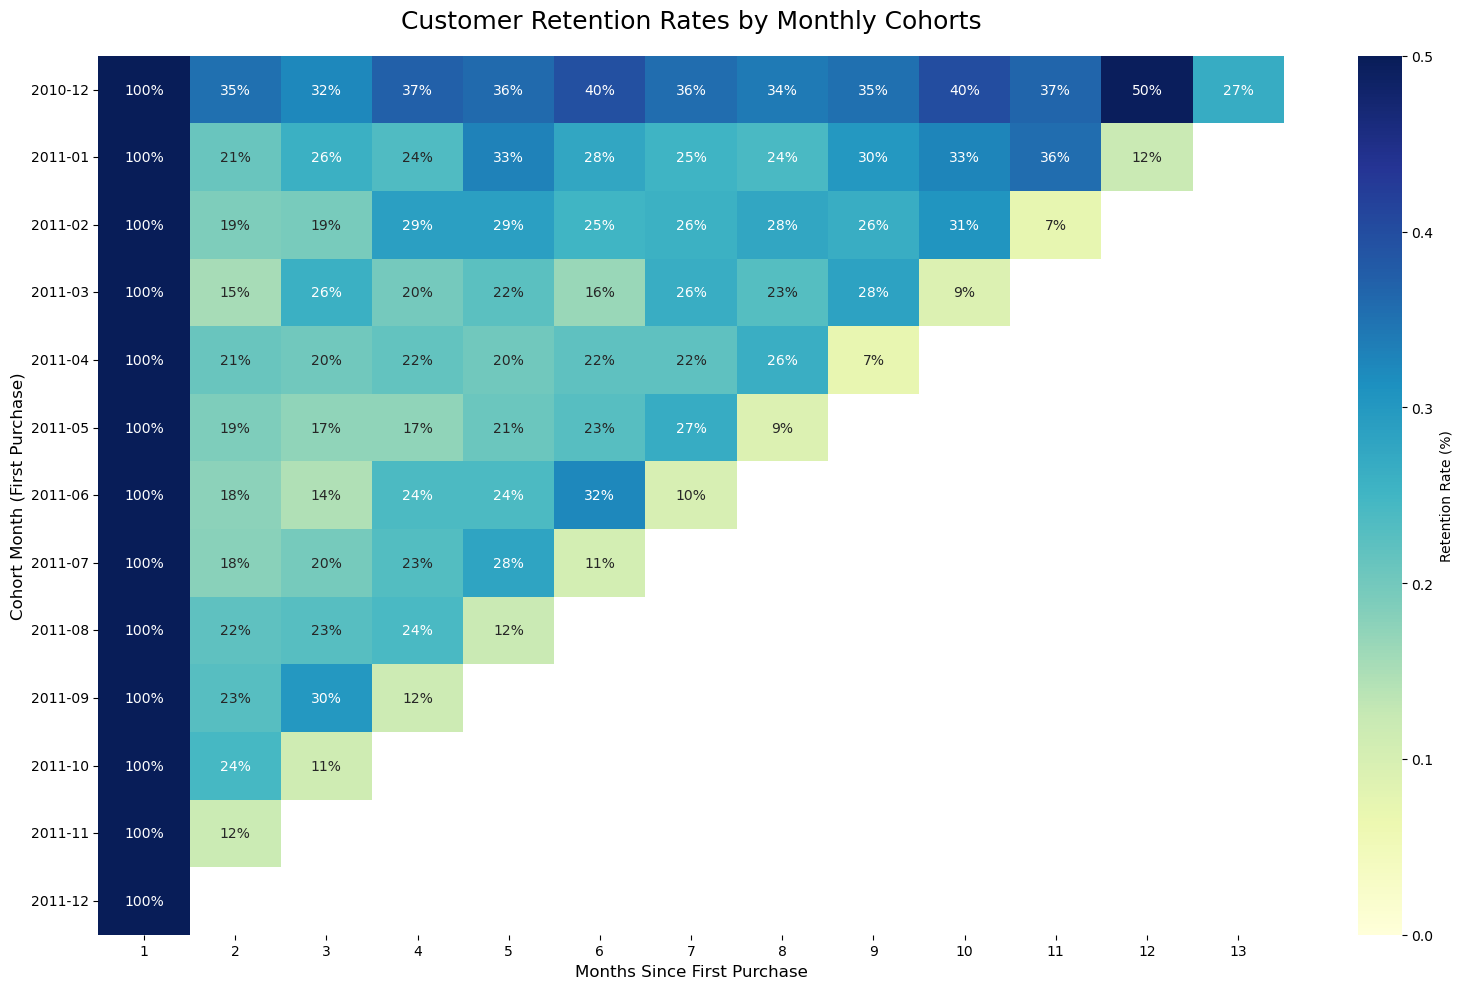

In [34]:
import datetime as dt

print("=== COHORT RETENTION ANALYSIS (OPTIMIZED) ===")

df['invoicedate'] = pd.to_datetime(df['invoicedate'])

print("\n--- 1. Calculating Cohorts & Time Offsets ---")
df['cohort_month'] = df.groupby('customerid')['invoicedate'].transform('min').dt.to_period('M')
df['order_month']  = df['invoicedate'].dt.to_period('M')
df['months_since_first'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n) + 1

print("\n--- 2. Building the Pivot Table ---")
cohort_data = df.groupby(['cohort_month', 'months_since_first'])['customerid'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='cohort_month', columns='months_since_first', values='customerid')
cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.index = retention.index.astype(str)

print("\n--- 3. Generating Heatmap ---")
plt.figure(figsize=(16, 10))
plt.title('Customer Retention Rates by Monthly Cohorts', fontsize=18, pad=20)

sns.heatmap(data=retention,
            annot=True,           
            fmt='.0%',            
            vmin=0.0,             
            vmax=0.5,             
            cmap='YlGnBu',        
            cbar_kws={'label': 'Retention Rate (%)'})

plt.ylabel('Cohort Month (First Purchase)', fontsize=12)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.yticks(rotation=0) 

plt.tight_layout()
plt.savefig('cohort_retention_heatmap_optimized.png', dpi=300)

In [36]:
rfm.to_csv('rfm.csv', index=False)